# Extending the Validated Workflow to Dopamine and Serotonin Sensors

## Overview

After validating the spectrometer-based workflow using the calcium-sensor test pair, the final step was to determine whether the same acquisition, alignment, and normalization logic could be extended to a different biological signal combination. To test this, dopamine and serotonin sensor recordings were processed using the same event-aligned workflow, including MATLAB-to-Python transfer, reward-aligned segmentation, and normalized comparison.

The purpose of this section was not to redefine the pipeline for a new use case, but to evaluate whether the previously validated workflow remained interpretable when applied to a different neurotransmitter-sensor pair. This final extension step therefore functions as a test of workflow generalizability rather than as an independent analysis path.

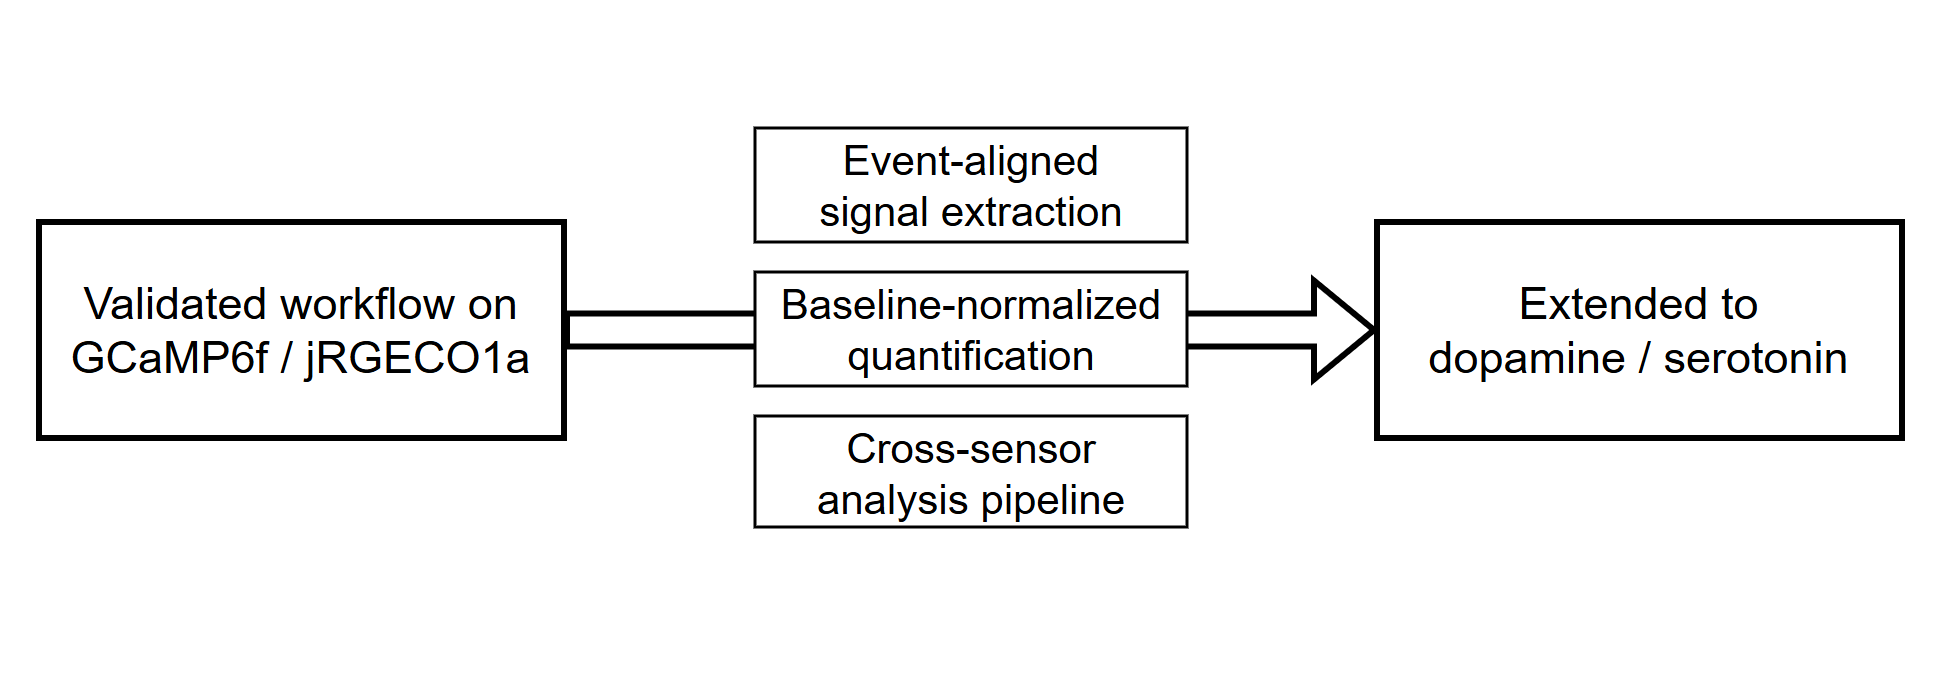

In [1]:
from pathlib import Path
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd()
ASSET_DIR = NOTEBOOK_DIR.parent / "assets" / "figures"
image_path = ASSET_DIR / "gca_to_dopa.png"

display(Image(filename=str(image_path), width=1000))

**Figure 1. Extension of the validated workflow from the calcium-sensor test pair to dopamine/serotonin sensor data.**  
The same acquisition-to-analysis structure was retained so that workflow generalizability could be evaluated without redefining the core processing logic.

## Applying the Existing Workflow to a New Sensor Pair

The processed dataset generated in the earlier MATLAB-based pipeline was used directly as the starting point for this extension step. Rather than introducing a new preprocessing structure, the same transferred dataset format and event-aligned analysis logic were retained so that dopamine and serotonin signals could be evaluated within the existing workflow.

This design choice was important because the objective of the final section was not to introduce a new analysis path, but to demonstrate that the previously validated workflow remained reusable when transferred to a different neurotransmitter-sensor pair.

In [4]:
from pathlib import Path
from scipy.io import loadmat
import numpy as np

# Load the dopamine/serotonin dataset generated by the existing workflow
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "sample"
file_path = DATA_DIR / "stimuli_python.mat"

data = loadmat(file_path)
photo1 = data["photo1"].flatten()
photo2 = data["photo2"].flatten()
sol1times = data["sol1times"].flatten()
downsamplingrate = int(data["downsamplingrate"][0][0])

## Event-Aligned and Normalized Signal Comparison

Using reward delivery as the reference event, dopamine and serotonin fluorescence signals were segmented into event-aligned trials and converted into comparable time-series representations. This step applied the same temporal logic used throughout the calcium-sensor validation workflow, allowing both neurotransmitter-associated signals to be interpreted relative to the same behavioral event.

Trial-level heatmaps were used first as an intermediate structural check to confirm that event-related organization remained visible across repeated trials rather than as the primary basis for interpretation. Because the raw signal changes remained relatively subtle, normalized comparison was then required in order to evaluate the two channels on a common scale.

Z-score transformation was therefore applied using the same baseline-referenced normalization logic established in the earlier sections. The resulting standardized traces allowed dopamine and serotonin responses to be compared within a shared event-aligned framework.

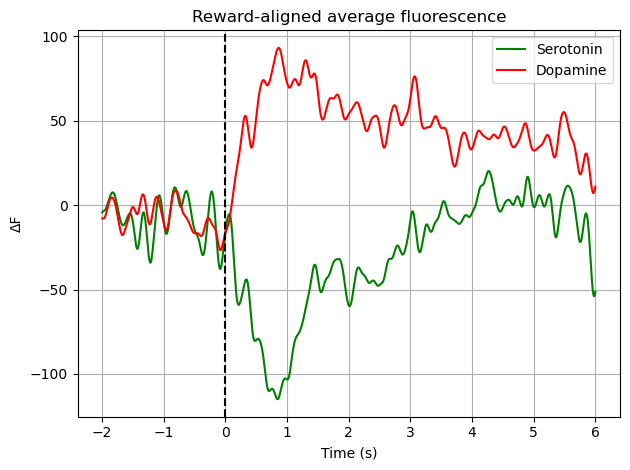

In [6]:
import matplotlib.pyplot as plt

# Define the reward-aligned extraction window for event-based comparison
pre, post = 2, 6  # Reward-aligned window: -2 s to +6 s

# Use reward timestamps extracted from the MATLAB/LabVIEW workflow
n_trials = len(sol1times)

photometry1_sol1 = []
photometry2_sol1 = []


for t in sol1times:
    # Convert each reward timestamp to the corresponding sample index
    idx = int(t * downsamplingrate)

    # Extract the reward-aligned segment from -2 s to +6 s
    start = idx - int(pre * downsamplingrate)
    end = idx + int(post * downsamplingrate)

    if start >= 0 and end < len(photo1):

        # Compute the pre-reward baseline from -3 s to -2 s
        # Subtract the baseline to center each reward-aligned segment
        base_start = idx - int(3 * downsamplingrate)
        base_end = idx - int(2 * downsamplingrate)
        baseline1 = np.mean(photo1[base_start:base_end])
        baseline2 = np.mean(photo2[base_start:base_end])

        segment1 = photo1[start:end] - baseline1
        segment2 = photo2[start:end] - baseline2

        photometry1_sol1.append(segment1)
        photometry2_sol1.append(segment2)

# Making every trials to 2d array
photometry1_sol1 = np.array(photometry1_sol1)
photometry2_sol1 = np.array(photometry2_sol1)

# Setting x-axis (time (s))
time_vec = np.linspace(-pre, post, photometry1_sol1.shape[1])

plt.plot(time_vec, photometry1_sol1.mean(axis=0), color='green', label='Serotonin')
plt.plot(time_vec, photometry2_sol1.mean(axis=0), color='red', label='Dopamine')
plt.axvline(0, linestyle='--', color='black')  # reward time
plt.title('Reward-aligned average fluorescence')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


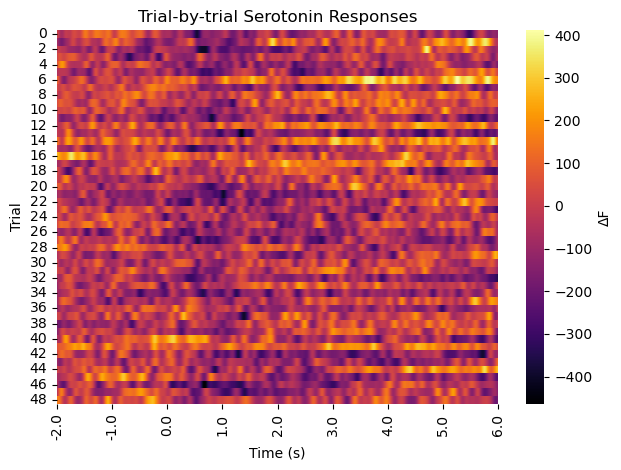

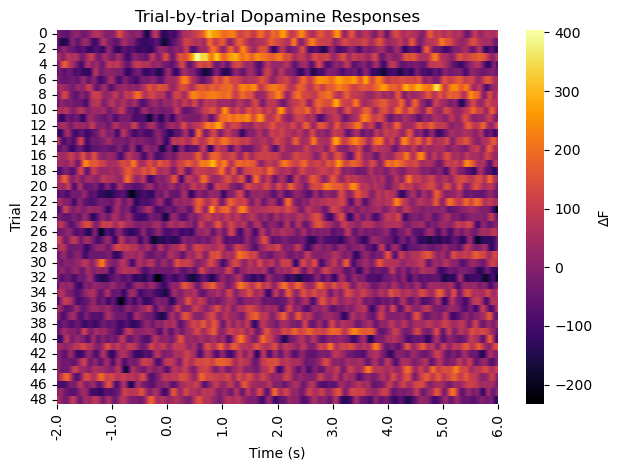

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

time_vec = np.linspace(-pre, post, photometry1_sol1.shape[1])

# Visualize trial-by-trial serotonin responses as a structural heatmap
sns.heatmap(photometry1_sol1, cmap='inferno', cbar_kws={'label': 'ΔF'})
plt.xticks(
    ticks=np.linspace(0, len(time_vec)-1, 9),
    labels=[f"{t:.1f}" for t in np.linspace(-pre, post, 9)]
)
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.title('Trial-by-trial Serotonin Responses')
plt.tight_layout()
plt.show()

# Visualize trial-by-trial dopamine responses as a structural heatmap
sns.heatmap(photometry2_sol1, cmap='inferno', cbar_kws={'label': 'ΔF'})
plt.xticks(
    ticks=np.linspace(0, len(time_vec)-1, 9),
    labels=[f"{t:.1f}" for t in np.linspace(-pre, post, 9)]
)
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.title('Trial-by-trial Dopamine Responses')
plt.tight_layout()
plt.show()

**Figure 2. Trial-by-trial event-aligned heatmaps for serotonin and dopamine signals.**  
Reward-aligned fluorescence segments were visualized across individual trials to confirm that event-related temporal organization remained visible after transfer of the workflow to the dopamine/serotonin dataset. These heatmaps were used as an intermediate structural check rather than as the primary basis for interpretation.

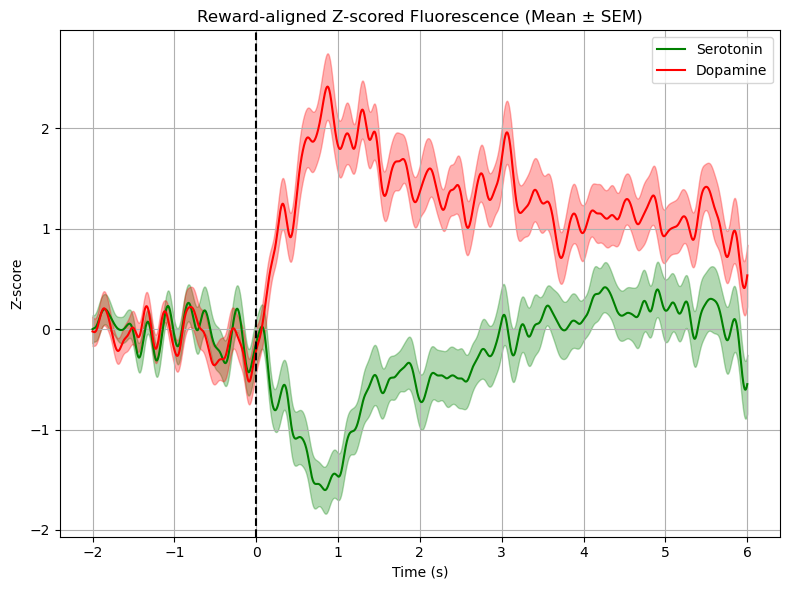

In [48]:
# Convert each reward-aligned trial to a z-score representation
# Use a pre-reward interval as the normalization baseline

def zscore_trials(trial_matrix, downsamplingrate, baseline_start=-2, baseline_end=-1):
    baseline_start_idx = int((baseline_start + pre) * downsamplingrate)
    baseline_end_idx = int((baseline_end + pre) * downsamplingrate)

    z_matrix = []
    for trial in trial_matrix:
        if baseline_end_idx > len(trial):
            continue
        baseline = trial[baseline_start_idx:baseline_end_idx]
        if len(baseline) == 0 or np.std(baseline) == 0:
            z_matrix.append(np.full_like(trial, np.nan))
        else:
            mean_base = np.mean(baseline)
            std_base = np.std(baseline)
            z_trial = (trial - mean_base) / std_base
            z_matrix.append(z_trial)

    return np.array(z_matrix)

# Application
z_photometry1_sol1 = zscore_trials(photometry1_sol1, downsamplingrate)
z_photometry2_sol1 = zscore_trials(photometry2_sol1, downsamplingrate)

time_vec = np.linspace(-pre, post, z_photometry1_sol1.shape[1])

# Mean and Standard Error of the Mean (SEM)
mean_green = np.nanmean(z_photometry1_sol1, axis=0)
sem_green = np.nanstd(z_photometry1_sol1, axis=0) / np.sqrt(np.sum(~np.isnan(z_photometry1_sol1), axis=0))

mean_red = np.nanmean(z_photometry2_sol1, axis=0)
sem_red = np.nanstd(z_photometry2_sol1, axis=0) / np.sqrt(np.sum(~np.isnan(z_photometry2_sol1), axis=0))

# Plot
plt.figure(figsize=(8, 6))

# Drawing graph for Serotonin
plt.plot(time_vec, mean_green, color='green', label='Serotonin')
plt.fill_between(time_vec, mean_green - sem_green, mean_green + sem_green, color='green', alpha=0.3)

# Drawing graph for Dopamine
plt.plot(time_vec, mean_red, color='red', label='Dopamine')
plt.fill_between(time_vec, mean_red - sem_red, mean_red + sem_red, color='red', alpha=0.3)

plt.axvline(0, linestyle='--', color='black')

plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.title('Reward-aligned Z-scored Fluorescence (Mean ± SEM)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



**Figure 3. Event-aligned z-score comparison of serotonin and dopamine responses.**  
Reward-aligned dopamine and serotonin signals were normalized relative to their own pre-reward baseline variability and then averaged across trials. The resulting mean ± SEM traces provide the final standardized comparison used to evaluate whether the validated workflow remained interpretable after transfer to a different neurotransmitter-sensor pair.

## Outcome

This final section extended the previously validated photometry workflow beyond the calcium-sensor test pair and applied the same acquisition-to-analysis logic to a dopamine/serotonin sensor combination. The successful extraction of reward-aligned and normalized dopamine and serotonin signals showed that the workflow was not restricted to a single biological pair or to one specific sensor-validation scenario.

In practical terms, this result supports the broader use of the spectrometer-based system as a flexible platform for simultaneous multi-signal measurement under behaviorally relevant conditions. Taken together with the earlier calcium-sensor validation, contamination analysis, correction-algorithm development, and before/after evaluation, this final extension step supports the conclusion that the workflow functions not as a pair-specific analysis routine, but as a generalizable platform for multi-sensor photometry experiments.